# Phase 0 — EDA & Setup

**Source plan:** `docs/fathomnet_2026_master_plan_v5.md` (Phase 0, lines ~307–416)

This notebook produces every Phase 0 deliverable required by the master plan.

| # | Deliverable | Output path | Cell |
|---|---|---|---|
| 1 | `cat_id` two-way mapping | `configs/cat_id_mapping.py` | 4 |
| 2 | Per-class instance counts | `data/class_counts.json` | 5 |
| 3 | PU severity (single-category-image rate) | printed + decisions file | 6 |
| 4 | Object size distribution | printed + decisions file | 7 |
| 5 | RFS repeat factors per image | `data/rfs_repeat_factors.pkl` | 8 |
| 6 | 5-fold stratified CV split | `data/cv_folds.pkl` | 9 |
| 7 | YOLO dataset config | `configs/fathomnet.yaml` | 10 |
| 8 | Marine taxonomy stub | `configs/taxonomy.py` | 11 |
| 9 | Image color statistics (deferred) | printed + decisions file | 12 |
| 10 | Decision summary | `notes/phase0_decisions.md` | 13 |

**Run order:** Execute cells top to bottom. Cell 12 (color stats) needs train images on disk; if the download isn't finished it auto-falls-back to whatever subset is available.

**Inputs read from disk:**
- `data/raw/train_dataset.json`
- `data/raw/test_dataset.json`
- `data/raw/images/train/*.png` (cell 12 only)

## 1 — Imports & paths

In [1]:
from __future__ import annotations

import json
import math
import pickle
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
CONFIGS_DIR = PROJECT_ROOT / "configs"
NOTES_DIR = PROJECT_ROOT / "notes"
TRAIN_IMG_DIR = RAW_DIR / "images" / "train"
TEST_IMG_DIR = RAW_DIR / "images" / "test"

TRAIN_JSON = RAW_DIR / "train_dataset.json"
TEST_JSON = RAW_DIR / "test_dataset.json"

for d in (DATA_DIR, CONFIGS_DIR, NOTES_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PROJECT_ROOT      : {PROJECT_ROOT}")
print(f"TRAIN_JSON exists : {TRAIN_JSON.exists()}")
print(f"TEST_JSON  exists : {TEST_JSON.exists()}")
print(f"Train img dir     : {TRAIN_IMG_DIR}  (count = {len(list(TRAIN_IMG_DIR.glob('*'))) if TRAIN_IMG_DIR.exists() else 0})")
print(f"Test  img dir     : {TEST_IMG_DIR}  (count = {len(list(TEST_IMG_DIR.glob('*'))) if TEST_IMG_DIR.exists() else 0})")

PROJECT_ROOT      : C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026
TRAIN_JSON exists : True
TEST_JSON  exists : True
Train img dir     : C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\data\raw\images\train  (count = 809)
Test  img dir     : C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\data\raw\images\test  (count = 1425)


## 2 — Load JSONs & sanity-check counts

In [2]:
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_data = json.load(f)
with open(TEST_JSON, "r", encoding="utf-8") as f:
    test_data = json.load(f)

print("=== TRAIN ===")
print(f"  images      : {len(train_data['images'])}")
print(f"  annotations : {len(train_data['annotations'])}")
print(f"  categories  : {len(train_data['categories'])}")
print("=== TEST ===")
print(f"  images      : {len(test_data['images'])}")
print(f"  annotations : {len(test_data['annotations'])}  (expected 0 by design)")
print(f"  categories  : {len(test_data.get('categories', []))}")

EXPECTED_TRAIN_IMAGES = 6463
EXPECTED_TRAIN_ANNS = 22225
EXPECTED_CATEGORIES = 32
EXPECTED_TEST_IMAGES = 1425

assert len(train_data["images"]) == EXPECTED_TRAIN_IMAGES, "train image count drift"
assert len(train_data["annotations"]) == EXPECTED_TRAIN_ANNS, "train annotation count drift"
assert len(train_data["categories"]) == EXPECTED_CATEGORIES, "category count drift"
assert len(test_data["images"]) == EXPECTED_TEST_IMAGES, "test image count drift"
assert len(test_data["annotations"]) == 0, "test should have zero annotations (FLAG 5)"
print("\nAll sanity checks pass.")

=== TRAIN ===
  images      : 6463
  annotations : 22225
  categories  : 32
=== TEST ===
  images      : 1425
  annotations : 0  (expected 0 by design)
  categories  : 32

All sanity checks pass.


## 3 — Inspect the categories block

In [3]:
categories_df = pd.DataFrame(train_data["categories"]).sort_values("id").reset_index(drop=True)
categories_df

,id,name,supercategory
0,1,amphipod,
1,2,anemone,
2,3,barnacle,
3,4,benthic worm,
4,5,bivalve,
5,6,black coral,
6,7,bony fish,
7,8,brittle star,
8,9,calycophoran siphonophore,
9,10,chiton,


## 4 — Build `cat_id_to_idx` mapping  →  `configs/cat_id_mapping.py`

**[FLAG 1]** Category IDs are **non-contiguous** (1–41 with gaps). A naive `class_idx = category_id - 1` silently loses categories. We must persist an explicit two-way mapping that the entire pipeline (training, inference, submission) consumes.

In [4]:
coco_cat_ids = sorted(c["id"] for c in train_data["categories"])
id_to_name = {c["id"]: c["name"] for c in train_data["categories"]}

cat_id_to_idx = {cid: i for i, cid in enumerate(coco_cat_ids)}
idx_to_cat_id = {i: cid for i, cid in enumerate(coco_cat_ids)}
idx_to_name   = {i: id_to_name[cid] for i, cid in enumerate(coco_cat_ids)}

missing_ids = sorted(set(range(min(coco_cat_ids), max(coco_cat_ids) + 1)) - set(coco_cat_ids))
print(f"Min cat id : {min(coco_cat_ids)}")
print(f"Max cat id : {max(coco_cat_ids)}")
print(f"Total      : {len(coco_cat_ids)}")
print(f"Missing    : {missing_ids}")

py_lines = [
    '"""Auto-generated by notebooks/phase0_eda.ipynb. Do not edit by hand."""',
    '',
    '# COCO category_ids actually present in the FathomNet 2026 train split.',
    '# These are NOT contiguous (gaps at 12, 14, 16, 18, 21, 23, 31, 34, 39).',
    'COCO_CAT_IDS: list[int] = ' + repr(coco_cat_ids),
    '',
    '# Two-way mapping. Use cat_id_to_idx for training; idx_to_cat_id when',
    '# writing the submission CSV (the evaluator expects the original COCO id).',
    'cat_id_to_idx: dict[int, int] = ' + repr(cat_id_to_idx),
    'idx_to_cat_id: dict[int, int] = ' + repr(idx_to_cat_id),
    '',
    '# Index → human-readable name (for plots, taxonomy ops, and config files).',
    'idx_to_name: dict[int, str] = ' + repr(idx_to_name),
    '',
    'NUM_CLASSES: int = len(COCO_CAT_IDS)',
    '',
]
out_path = CONFIGS_DIR / "cat_id_mapping.py"
out_path.write_text("\n".join(py_lines), encoding="utf-8")
print(f"\nWrote: {out_path}")

Min cat id : 1
Max cat id : 41
Total      : 32
Missing    : [12, 14, 16, 18, 21, 23, 31, 34, 39]

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\configs\cat_id_mapping.py


## 5 — Class frequency  →  `data/class_counts.json`

In [5]:
class_counts: Counter[int] = Counter()
for ann in train_data["annotations"]:
    class_counts[ann["category_id"]] += 1

freq_df = (
    pd.DataFrame(
        [
            {
                "class_idx": cat_id_to_idx[cid],
                "category_id": cid,
                "name": id_to_name[cid],
                "count": class_counts[cid],
            }
            for cid in coco_cat_ids
        ]
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

max_count = freq_df["count"].max()
min_count = freq_df["count"].min()
imbalance_ratio = max_count / max(min_count, 1)

print(f"Top 5:\n{freq_df.head(5).to_string(index=False)}\n")
print(f"Bottom 5:\n{freq_df.tail(5).to_string(index=False)}\n")
print(f"Imbalance ratio (max/min) : {imbalance_ratio:.0f}:1")
print(f"Classes with <100 instances : {(freq_df['count'] < 100).sum()}")
print(f"Classes with <50  instances : {(freq_df['count'] < 50).sum()}")

out_path = DATA_DIR / "class_counts.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "by_category_id": {str(cid): int(class_counts[cid]) for cid in coco_cat_ids},
            "by_class_idx":   {str(cat_id_to_idx[cid]): int(class_counts[cid]) for cid in coco_cat_ids},
            "by_name":        {id_to_name[cid]: int(class_counts[cid]) for cid in coco_cat_ids},
            "imbalance_ratio": float(imbalance_ratio),
            "total_annotations": int(sum(class_counts.values())),
        },
        f,
        indent=2,
    )
print(f"\nWrote: {out_path}")

Top 5:
 class_idx  category_id         name  count
        31           41       urchin   5723
         6            7    bony fish   3069
        20           27      sea fan   3026
         7            8 brittle star   3013
        28           37       sponge   1213

Bottom 5:
 class_idx  category_id       name  count
        18           25   pyrosome     36
         2            3   barnacle     31
        13           17     isopod     28
        24           32 sea squirt     17
        22           29   sea slug      7

Imbalance ratio (max/min) : 818:1
Classes with <100 instances : 14
Classes with <50  instances : 9

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\data\class_counts.json


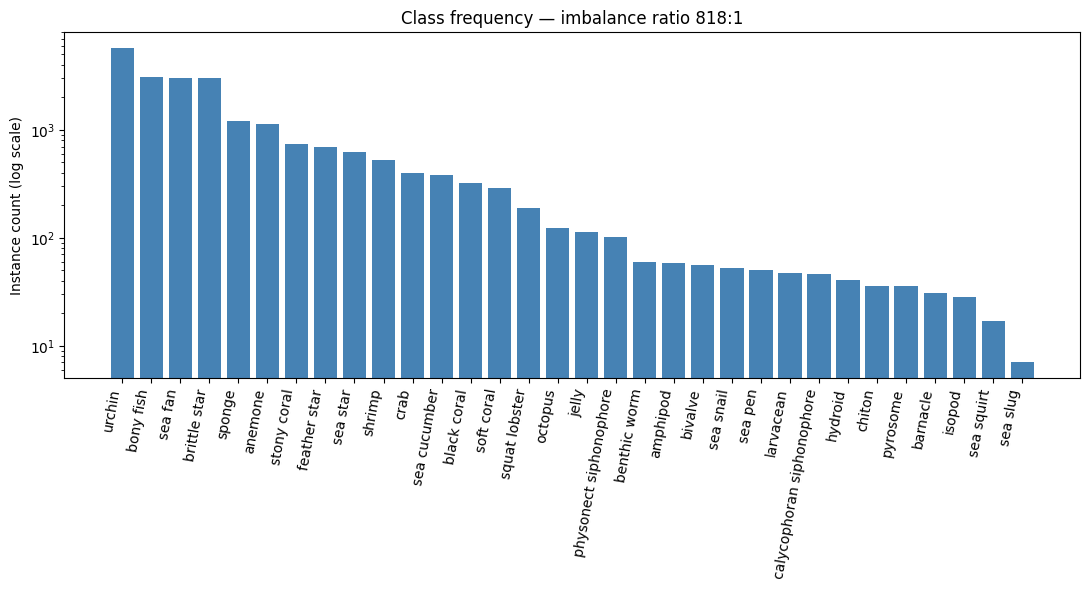

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(freq_df["name"], freq_df["count"], color="steelblue")
ax.set_yscale("log")
ax.set_ylabel("Instance count (log scale)")
ax.set_title(f"Class frequency — imbalance ratio {imbalance_ratio:.0f}:1")
ax.tick_params(axis="x", rotation=80)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")
plt.tight_layout()
plt.show()

## 6 — PU severity: % of images with only one category labeled

If many training images have only a single category labeled, the "unlabeled" regions inside them are very likely to contain unannotated positives of *other* classes — textbook PU. v5 plan thresholds:
- `> 50%` → prioritize Soft Teacher + Kiryo PU
- `30–50%` → standard PU handling
- `< 30%` → PU mild, focus on imbalance

In [7]:
img_to_cats: dict[int, set[int]] = defaultdict(set)
for ann in train_data["annotations"]:
    img_to_cats[ann["image_id"]].add(ann["category_id"])

n_train_images = len(train_data["images"])
n_with_anns = len(img_to_cats)
n_without_anns = n_train_images - n_with_anns

categories_per_image = pd.Series([len(s) for s in img_to_cats.values()])
single_cat_images = (categories_per_image == 1).sum()
single_cat_pct = 100.0 * single_cat_images / n_with_anns

annotations_per_image = pd.Series(
    [sum(1 for a in train_data["annotations"] if a["image_id"] == img_id) for img_id in img_to_cats]
) if False else None
ann_counts = Counter(a["image_id"] for a in train_data["annotations"])
annotations_per_image = pd.Series(list(ann_counts.values()))

print(f"Train images                    : {n_train_images}")
print(f"Train images with >=1 ann       : {n_with_anns}")
print(f"Train images with 0 anns        : {n_without_anns}  (expected 0 — see FLAG 6)")
print()
print(f"Median annotations per image    : {annotations_per_image.median():.1f}")
print(f"Mean   annotations per image    : {annotations_per_image.mean():.2f}")
print(f"Median categories  per image    : {categories_per_image.median():.1f}")
print(f"Mean   categories  per image    : {categories_per_image.mean():.2f}")
print()
print(f"Single-category images          : {single_cat_images} / {n_with_anns}")
print(f"PU severity (single-cat-image%) : {single_cat_pct:.1f}%")

if single_cat_pct > 50:
    pu_severity_band = "high"
elif single_cat_pct >= 30:
    pu_severity_band = "medium"
else:
    pu_severity_band = "low"
print(f"PU severity band                : {pu_severity_band.upper()}")

Train images                    : 6463
Train images with >=1 ann       : 6463
Train images with 0 anns        : 0  (expected 0 — see FLAG 6)

Median annotations per image    : 2.0
Mean   annotations per image    : 3.44
Median categories  per image    : 1.0
Mean   categories  per image    : 1.56

Single-category images          : 4038 / 6463
PU severity (single-cat-image%) : 62.5%
PU severity band                : HIGH


## 7 — Object size distribution

v5 thresholds (max-side length in pixels):
- `> 25%` of objects with max-side `< 64 px` → imgsz=1280, SAHI **critical**
- `10–25%` → imgsz=1024, SAHI helpful
- `< 10%` → imgsz=640, SAHI optional

Total objects                       : 22225
max-side <  32 px                   : 0.4%
max-side <  64 px                   : 5.1%
relative area < 1% of frame         : 67.2%

Recommended imgsz                   : 640
SAHI priority                       : OPTIONAL


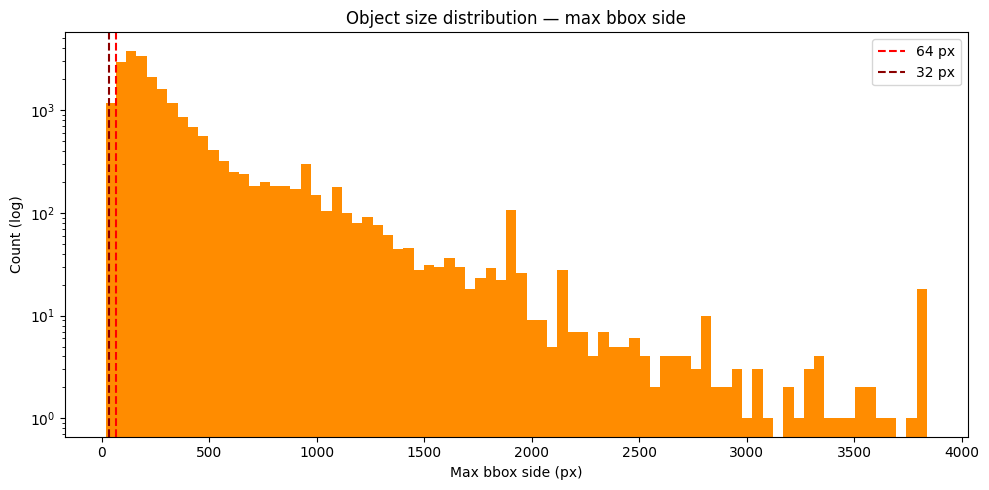

In [8]:
img_id_to_meta = {img["id"]: img for img in train_data["images"]}

rows = []
for ann in train_data["annotations"]:
    img = img_id_to_meta[ann["image_id"]]
    bw, bh = ann["bbox"][2], ann["bbox"][3]
    rows.append({
        "max_side_px": max(bw, bh),
        "area_px": bw * bh,
        "rel_area": (bw * bh) / float(img["width"] * img["height"]),
        "img_w": img["width"],
        "img_h": img["height"],
    })
obj_df = pd.DataFrame(rows)

small_pct = 100.0 * (obj_df["max_side_px"] < 64).mean()
tiny_pct = 100.0 * (obj_df["max_side_px"] < 32).mean()
rel_small_pct = 100.0 * (obj_df["rel_area"] < 0.01).mean()

print(f"Total objects                       : {len(obj_df)}")
print(f"max-side <  32 px                   : {tiny_pct:.1f}%")
print(f"max-side <  64 px                   : {small_pct:.1f}%")
print(f"relative area < 1% of frame         : {rel_small_pct:.1f}%")
print()
if small_pct > 25:
    imgsz_recommend = 1280
    sahi_priority = "CRITICAL"
elif small_pct >= 10:
    imgsz_recommend = 1024
    sahi_priority = "HELPFUL"
else:
    imgsz_recommend = 640
    sahi_priority = "OPTIONAL"
print(f"Recommended imgsz                   : {imgsz_recommend}")
print(f"SAHI priority                       : {sahi_priority}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(obj_df["max_side_px"], bins=80, color="darkorange", log=True)
ax.axvline(64, color="red", linestyle="--", label="64 px")
ax.axvline(32, color="darkred", linestyle="--", label="32 px")
ax.set_xlabel("Max bbox side (px)")
ax.set_ylabel("Count (log)")
ax.set_title("Object size distribution — max bbox side")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
train_resolutions = Counter((img["width"], img["height"]) for img in train_data["images"])
test_resolutions = Counter((img["width"], img["height"]) for img in test_data["images"])

def res_table(counter: Counter[tuple[int, int]], total: int) -> pd.DataFrame:
    return (
        pd.DataFrame(
            [{"resolution": f"{w}x{h}", "count": n, "share": n / total}
             for (w, h), n in counter.most_common()]
        )
    )

print("=== TRAIN ===")
print(res_table(train_resolutions, len(train_data["images"])).to_string(index=False))
print("\n=== TEST ===")
print(res_table(test_resolutions, len(test_data["images"])).to_string(index=False))

=== TRAIN ===
resolution  count    share
 1920x1080   3415 0.528392
 3840x2160   3048 0.471608

=== TEST ===
resolution  count    share
 1920x1080   1184 0.830877
   720x486    197 0.138246
 1920x1079     23 0.016140
 2048x1080     10 0.007018
   714x486      7 0.004912
   720x366      1 0.000702
   640x366      1 0.000702
   640x486      1 0.000702
   715x486      1 0.000702


## 8 — RFS repeat factors  →  `data/rfs_repeat_factors.pkl`

Repeat Factor Sampling (Gupta et al., LVIS): each image is shown more often if it contains a rare class. The standard formula is:

$$r_c = \max\left(1, \sqrt{t / f_c}\right)$$

where $f_c$ is the image-frequency of class $c$ (fraction of images containing it), and $t$ is a threshold. v5 plan recommends `t=0.005` for FathomNet given the 817:1 imbalance and rare classes (sea slug, 7 instances).

Per-image repeat factor = max over classes present in that image:

$$r_I = \max_{c \in I} r_c$$

In [10]:
RFS_THRESHOLD_T = 0.005
n_imgs = n_with_anns

image_freq_per_class: dict[int, int] = defaultdict(int)
for cats in img_to_cats.values():
    for cid in cats:
        image_freq_per_class[cid] += 1

class_repeat_factor: dict[int, float] = {}
for cid in coco_cat_ids:
    f_c = image_freq_per_class.get(cid, 0) / n_imgs
    class_repeat_factor[cid] = max(1.0, math.sqrt(RFS_THRESHOLD_T / max(f_c, 1e-12)))

rfs_class_df = (
    pd.DataFrame(
        [
            {
                "class_idx": cat_id_to_idx[cid],
                "name": id_to_name[cid],
                "image_freq": image_freq_per_class.get(cid, 0) / n_imgs,
                "repeat_factor": class_repeat_factor[cid],
            }
            for cid in coco_cat_ids
        ]
    )
    .sort_values("repeat_factor", ascending=False)
)
print("Top 10 by repeat factor:")
print(rfs_class_df.head(10).to_string(index=False))

image_repeat_factor: dict[int, float] = {}
for img_id, cats in img_to_cats.items():
    image_repeat_factor[img_id] = max(class_repeat_factor[c] for c in cats)

print(f"\nMean image repeat factor   : {np.mean(list(image_repeat_factor.values())):.3f}")
print(f"Max  image repeat factor   : {max(image_repeat_factor.values()):.3f}")
print(f"Min  image repeat factor   : {min(image_repeat_factor.values()):.3f}")

out_path = DATA_DIR / "rfs_repeat_factors.pkl"
with open(out_path, "wb") as f:
    pickle.dump(
        {
            "threshold_t": RFS_THRESHOLD_T,
            "class_repeat_factor_by_cat_id": class_repeat_factor,
            "class_repeat_factor_by_class_idx": {cat_id_to_idx[cid]: rf for cid, rf in class_repeat_factor.items()},
            "image_repeat_factor": image_repeat_factor,
        },
        f,
    )
print(f"\nWrote: {out_path}")

Top 10 by repeat factor:
 class_idx         name  image_freq  repeat_factor
        22     sea slug    0.001083       2.148588
        24   sea squirt    0.002630       1.378725
         2     barnacle    0.003559       1.185327
        13       isopod    0.003713       1.160370
         9       chiton    0.004951       1.004910
         5  black coral    0.044407       1.000000
         4      bivalve    0.006034       1.000000
         0     amphipod    0.007117       1.000000
         7 brittle star    0.144979       1.000000
         6    bony fish    0.291505       1.000000

Mean image repeat factor   : 1.004
Max  image repeat factor   : 2.149
Min  image repeat factor   : 1.000

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\data\rfs_repeat_factors.pkl


## 9 — 5-fold stratified CV split  →  `data/cv_folds.pkl`

Multi-label stratification is the right answer (skmultilearn IterativeStratification), but to keep dependencies minimal we approximate it: stratify on the **rarest class present in each image**. This guarantees every rare class is split as evenly as possible across folds — which is the part that matters for unbiased per-class AP.

In [11]:
N_FOLDS = 5
rarity_rank = {cid: rank for rank, cid in enumerate(
    sorted(coco_cat_ids, key=lambda c: image_freq_per_class.get(c, 0))
)}

img_ids_sorted = sorted(img_to_cats.keys())
rarest_class_label = np.array(
    [min(img_to_cats[img_id], key=lambda c: image_freq_per_class.get(c, 0)) for img_id in img_ids_sorted]
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
folds: list[dict] = []
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(img_ids_sorted, rarest_class_label)):
    train_img_ids = [img_ids_sorted[i] for i in train_idx]
    val_img_ids   = [img_ids_sorted[i] for i in val_idx]
    folds.append({
        "fold": fold_idx,
        "train_image_ids": train_img_ids,
        "val_image_ids": val_img_ids,
    })
    print(f"Fold {fold_idx}: train={len(train_img_ids)}  val={len(val_img_ids)}")

print("\nPer-fold per-class image counts (rarest 6 classes):")
rarest_six_cids = sorted(coco_cat_ids, key=lambda c: image_freq_per_class.get(c, 0))[:6]
for cid in rarest_six_cids:
    counts_per_fold = []
    for fold in folds:
        n = sum(1 for img_id in fold["val_image_ids"] if cid in img_to_cats[img_id])
        counts_per_fold.append(n)
    print(f"  {id_to_name[cid]:25s} (cid={cid:2d}): val counts per fold = {counts_per_fold}")

out_path = DATA_DIR / "cv_folds.pkl"
with open(out_path, "wb") as f:
    pickle.dump(
        {
            "n_folds": N_FOLDS,
            "random_seed": RANDOM_SEED,
            "stratified_on": "rarest_class_per_image",
            "folds": folds,
        },
        f,
    )
print(f"\nWrote: {out_path}")

Fold 0: train=5170  val=1293
Fold 1: train=5170  val=1293
Fold 2: train=5170  val=1293
Fold 3: train=5171  val=1292
Fold 4: train=5171  val=1292

Per-fold per-class image counts (rarest 6 classes):
  sea slug                  (cid=29): val counts per fold = [1, 2, 2, 1, 1]
  sea squirt                (cid=32): val counts per fold = [4, 3, 3, 3, 4]
  barnacle                  (cid= 3): val counts per fold = [4, 4, 5, 5, 5]
  isopod                    (cid=17): val counts per fold = [5, 5, 4, 5, 5]
  chiton                    (cid=10): val counts per fold = [6, 7, 7, 6, 6]
  hydroid                   (cid=15): val counts per fold = [6, 7, 7, 7, 6]

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\data\cv_folds.pkl


## 10 — YOLO dataset config  →  `configs/fathomnet.yaml`

Ultralytics expects a YAML pointing at image directories and listing class names by **0-indexed class_idx**. Note: this stub points at the raw image directory; before training in Phase 2 you'll generate per-fold image lists (`train_fold0.txt`, `val_fold0.txt`) from `cv_folds.pkl` and the YAML will reference those instead.

In [12]:
import yaml

yolo_config = {
    "path": str((DATA_DIR / "raw").resolve()).replace("\\", "/"),
    "train": "images/train",
    "val":   "images/train",
    "test":  "images/test",
    "nc": len(coco_cat_ids),
    "names": {idx: idx_to_name[idx] for idx in range(len(coco_cat_ids))},
    "_phase0_meta": {
        "note": "This stub points at raw images. Per-fold txt lists will override 'train'/'val' before Phase 2 baselines.",
        "coco_cat_ids": coco_cat_ids,
        "imgsz_recommended": imgsz_recommend,
        "rfs_threshold_t": RFS_THRESHOLD_T,
    },
}
out_path = CONFIGS_DIR / "fathomnet.yaml"
with open(out_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(yolo_config, f, sort_keys=False)
print(f"Wrote: {out_path}")
print(out_path.read_text(encoding="utf-8"))

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\configs\fathomnet.yaml
path: C:/Users/navya/OneDrive/Documentos/projects/fathomnet-2026/data/raw
train: images/train
val: images/train
test: images/test
nc: 32
names:
  0: amphipod
  1: anemone
  2: barnacle
  3: benthic worm
  4: bivalve
  5: black coral
  6: bony fish
  7: brittle star
  8: calycophoran siphonophore
  9: chiton
  10: crab
  11: feather star
  12: hydroid
  13: isopod
  14: jelly
  15: larvacean
  16: octopus
  17: physonect siphonophore
  18: pyrosome
  19: sea cucumber
  20: sea fan
  21: sea pen
  22: sea slug
  23: sea snail
  24: sea squirt
  25: sea star
  26: shrimp
  27: soft coral
  28: sponge
  29: squat lobster
  30: stony coral
  31: urchin
_phase0_meta:
  note: This stub points at raw images. Per-fold txt lists will override 'train'/'val'
    before Phase 2 baselines.
  coco_cat_ids:
  - 1
  - 2
  - 3
  - 4
  - 5
  - 6
  - 7
  - 8
  - 9
  - 10
  - 11
  - 13
  - 15
  - 17
  - 19
  - 20
  - 2

## 11 — Marine taxonomy stub  →  `configs/taxonomy.py`

Phase 5 (hierarchical loss) needs a coarse marine taxonomy that groups the 32 fine classes. A naive grouping is enough for Phase 0; you'll refine it in Phase 5 with WoRMS lookups. The point of writing it now is so any code that imports `taxonomy.GROUPS` already finds something coherent.

In [13]:
TAXONOMY_HINTS = {
    "fish":          ["bony fish", "eel", "flatfish", "ray", "shark"],
    "cephalopod":    ["squid", "octopus"],
    "crustacean":    ["crab", "shrimp", "isopod", "lobster", "krill"],
    "echinoderm":    ["urchin", "sea star", "sea cucumber", "feather star", "crinoid", "brittle star"],
    "cnidarian":     ["sea fan", "coral", "anemone", "jellyfish", "hydroid", "sea pen"],
    "sponge":        ["sponge", "glass sponge"],
    "mollusk_other": ["sea slug", "snail", "clam", "mussel", "sea squirt"],
    "worm":          ["worm", "polychaete", "tube worm"],
    "other":         [],
}

def assign_group(name: str) -> str:
    n = name.lower()
    for group, hints in TAXONOMY_HINTS.items():
        if any(h in n for h in hints):
            return group
    return "other"

groups: dict[str, list[int]] = defaultdict(list)
for idx in range(len(coco_cat_ids)):
    groups[assign_group(idx_to_name[idx])].append(idx)

for g, members in sorted(groups.items()):
    names = [idx_to_name[i] for i in members]
    print(f"{g:18s} ({len(members)}): {names}")

py_lines = [
    '"""Auto-generated marine taxonomy stub. Refine in Phase 5 with WoRMS lookups.',
    '   GROUPS values are 0-indexed class_idx (NOT COCO category_id).',
    '"""',
    '',
    'from typing import Iterable',
    '',
    'GROUPS: dict[str, list[int]] = ' + repr(dict(groups)),
    '',
    '_idx_to_group = {idx: g for g, members in GROUPS.items() for idx in members}',
    '',
    'def group_of(class_idx: int) -> str:',
    '    return _idx_to_group.get(class_idx, "other")',
    '',
    'def members_of(group: str) -> Iterable[int]:',
    '    return GROUPS.get(group, [])',
    '',
]
out_path = CONFIGS_DIR / "taxonomy.py"
out_path.write_text("\n".join(py_lines), encoding="utf-8")
print(f"\nWrote: {out_path}")

cephalopod         (1): ['octopus']
cnidarian          (7): ['anemone', 'black coral', 'hydroid', 'sea fan', 'sea pen', 'soft coral', 'stony coral']
crustacean         (4): ['crab', 'isopod', 'shrimp', 'squat lobster']
echinoderm         (5): ['brittle star', 'feather star', 'sea cucumber', 'sea star', 'urchin']
fish               (1): ['bony fish']
mollusk_other      (3): ['sea slug', 'sea snail', 'sea squirt']
other              (9): ['amphipod', 'barnacle', 'bivalve', 'calycophoran siphonophore', 'chiton', 'jelly', 'larvacean', 'physonect siphonophore', 'pyrosome']
sponge             (1): ['sponge']
worm               (1): ['benthic worm']

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\configs\taxonomy.py


## 12 — (Deferred) Image color statistics

Needs actual image bytes. v5 says ~100 sample images is enough. We sample randomly from whatever is on disk — if the train download is still running, this just runs on the partial set, which is fine for the gray-world / CLAHE decision.

In [14]:
import cv2

MIN_SAMPLE = 100
available = sorted(TRAIN_IMG_DIR.glob("*")) if TRAIN_IMG_DIR.exists() else []
if len(available) < 30:
    print(f"Only {len(available)} train images on disk. Skipping color stats — re-run this cell after download finishes.")
else:
    sample = random.sample(available, min(MIN_SAMPLE, len(available)))
    bgr_means = []
    bgr_stds = []
    hsv_v_stds = []
    bad = []
    for p in sample:
        img = cv2.imread(str(p))
        if img is None:
            bad.append(p)
            continue
        bgr_means.append(img.reshape(-1, 3).mean(axis=0))
        bgr_stds.append(img.reshape(-1, 3).std(axis=0))
        hsv_v_stds.append(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[..., 2].std())
    bgr_means = np.array(bgr_means).mean(axis=0) / 255.0
    bgr_stds = np.array(bgr_stds).mean(axis=0) / 255.0
    hsv_v_std = float(np.mean(hsv_v_stds))
    b_mean, g_mean, r_mean = bgr_means.tolist()
    print(f"Sampled {len(sample) - len(bad)} images (failed: {len(bad)}).")
    print(f"Mean BGR (0-1) : B={b_mean:.3f}  G={g_mean:.3f}  R={r_mean:.3f}")
    print(f"Std  BGR (0-1) : {bgr_stds.tolist()}")
    print(f"Mean HSV V std : {hsv_v_std:.1f}")
    underwater_preproc = r_mean < 0.7 * max(b_mean, g_mean)
    clahe_recommend = hsv_v_std > 50
    print(f"\nUnderwater preproc (gray-world) recommended : {underwater_preproc}")
    print(f"CLAHE recommended (V std > 50)              : {clahe_recommend}")

Sampled 100 images (failed: 0).
Mean BGR (0-1) : B=0.328  G=0.373  R=0.257
Std  BGR (0-1) : [0.14173689883415608, 0.18344745288538147, 0.15430756816066848]
Mean HSV V std : 45.7

Underwater preproc (gray-world) recommended : True
CLAHE recommended (V std > 50)              : False


## 13 — Decision summary  →  `notes/phase0_decisions.md`

In [15]:
decisions_md = f"""# Phase 0 Decisions

Generated by `notebooks/phase0_eda.ipynb`. Source: `docs/fathomnet_2026_master_plan_v5.md`.

## Dataset shape

- Train images: **{n_train_images}** | annotations: **{len(train_data['annotations'])}** | categories: **{len(coco_cat_ids)}**
- Test images: **{len(test_data['images'])}** (annotations empty by design — FLAG 5)
- Median annotations / image: **{annotations_per_image.median():.1f}**
- Median categories  / image: **{categories_per_image.median():.1f}**

## Class imbalance

- Imbalance ratio (max/min instances): **{imbalance_ratio:.0f}:1**
- Classes with `< 100` instances: **{(freq_df['count'] < 100).sum()}**
- Classes with `< 50`  instances: **{(freq_df['count'] < 50).sum()}**
- Top 3:    {', '.join(f"{r['name']} ({r['count']})" for _, r in freq_df.head(3).iterrows())}
- Bottom 3: {', '.join(f"{r['name']} ({r['count']})" for _, r in freq_df.tail(3).iterrows())}

## PU severity

- Single-category-image rate: **{single_cat_pct:.1f}%**  →  band: **{pu_severity_band.upper()}**

## Object size

- Objects with max-side `< 64 px`: **{small_pct:.1f}%**
- Objects with max-side `< 32 px`: **{tiny_pct:.1f}%**
- Objects with relative area `< 1%`: **{rel_small_pct:.1f}%**
- Recommended `imgsz`: **{imgsz_recommend}**
- SAHI priority: **{sahi_priority}**

## Decision table outcomes (per v5 thresholds)

| Decision | v5 trigger | Result |
|---|---|---|
| Include EFL? | imbalance ratio > 10 | **{'YES' if imbalance_ratio > 10 else 'no'}** |
| Include RFS? | classes with <100 instances > 5 | **{'YES' if (freq_df['count'] < 100).sum() > 5 else 'no'}** |
| Include class-aware copy-paste? | classes with <50 instances > 3 | **{'YES' if (freq_df['count'] < 50).sum() > 3 else 'no'}** |
| Include SAHI? | small-object % > 25 OR test resolution varies | **YES** (FLAG 4: 14% test at 720x486) |
| Include multi-scale training? | distribution shift between train/test | **YES** |
| Soft Teacher / Kiryo PU? | single-cat-image rate > 50% | **{'YES' if single_cat_pct > 50 else 'standard PU sufficient'}** |

## Artifacts produced

- `configs/cat_id_mapping.py`  — two-way COCO↔class_idx mapping (FLAG 1)
- `configs/fathomnet.yaml`     — YOLO dataset stub
- `configs/taxonomy.py`        — marine taxonomy stub (refine in Phase 5)
- `data/class_counts.json`     — per-class instance counts
- `data/rfs_repeat_factors.pkl` — RFS factors (t={RFS_THRESHOLD_T})
- `data/cv_folds.pkl`          — 5-fold stratified split (rarest-class strat)
- `notes/phase0_decisions.md`  — this file

## Next step

**Phase 2 baselines** on Kaggle's free T4 — see plan v5 lines 481–527.
Use `cv_folds.pkl` fold 0 as the held-out val set for the first YOLOv11m baseline.
"""
out_path = NOTES_DIR / "phase0_decisions.md"
out_path.write_text(decisions_md, encoding="utf-8")
print(f"Wrote: {out_path}")
print()
print(decisions_md)

Wrote: C:\Users\navya\OneDrive\Documentos\projects\fathomnet-2026\notes\phase0_decisions.md

# Phase 0 Decisions

Generated by `notebooks/phase0_eda.ipynb`. Source: `docs/fathomnet_2026_master_plan_v5.md`.

## Dataset shape

- Train images: **6463** | annotations: **22225** | categories: **32**
- Test images: **1425** (annotations empty by design — FLAG 5)
- Median annotations / image: **2.0**
- Median categories  / image: **1.0**

## Class imbalance

- Imbalance ratio (max/min instances): **818:1**
- Classes with `< 100` instances: **14**
- Classes with `< 50`  instances: **9**
- Top 3:    urchin (5723), bony fish (3069), sea fan (3026)
- Bottom 3: isopod (28), sea squirt (17), sea slug (7)

## PU severity

- Single-category-image rate: **62.5%**  →  band: **HIGH**

## Object size

- Objects with max-side `< 64 px`: **5.1%**
- Objects with max-side `< 32 px`: **0.4%**
- Objects with relative area `< 1%`: **67.2%**
- Recommended `imgsz`: **640**
- SAHI priority: **OPTIONAL**

## Decisi